# Optimize Bag-of-SIFT + SVM

这个 notebook 用于调优 `LinearSVC` 的 `C`，并在测试集上评估最优模型。
输出会保存到 `outputs/opt_svm/`。

In [18]:
import os

import os.path as osp

import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.svm import LinearSVC

from sklearn.preprocessing import StandardScaler, normalize



from student_code_12311805 import get_bags_of_sifts

from utils import get_image_paths

In [19]:
OUTDIR = 'outputs/opt_svm'
os.makedirs(OUTDIR, exist_ok=True)

categories = ['Kitchen','Store','Bedroom','LivingRoom','Office','Industrial','Suburb',
              'InsideCity','TallBuilding','Street','Highway','OpenCountry','Coast',
              'Mountain','Forest']
num_train_per_cat = 100
vocab_filename = 'vocab.pkl'

# 可调参数
C_values = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
val_ratio = 0.2
split_seed = 42

data_path = osp.join('..', 'data')
train_image_paths, test_image_paths, train_labels, test_labels = get_image_paths(
    data_path, categories, num_train_per_cat
)

print('Train images:', len(train_image_paths), 'Test images:', len(test_image_paths))

Train images: 1500 Test images: 1500


In [20]:
print('Computing bag-of-sift features...')
train_bags = np.asarray(get_bags_of_sifts(train_image_paths, vocab_filename))
test_bags = np.asarray(get_bags_of_sifts(test_image_paths, vocab_filename))

print('train_bags:', train_bags.shape, 'test_bags:', test_bags.shape)

Computing bag-of-sift features...
train_bags: (1500, 200) test_bags: (1500, 200)


In [21]:
# 训练集划分出验证集，用于挑选最优配置

results = []

sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=split_seed)

train_idx, val_idx = next(sss.split(train_bags, train_labels))



X_train = train_bags[train_idx]

y_train = np.array([train_labels[i] for i in train_idx])

X_val = train_bags[val_idx]

y_val = np.array([train_labels[i] for i in val_idx])



# 两种特征预处理：raw 和 sqrt+L2(Hellinger)

feature_modes = ['raw', 'sqrt_l2']

C_values = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 3.0, 10.0]

loss_values = ['hinge', 'squared_hinge']

class_weight_values = [None, 'balanced']



def transform_features(X, mode):

    if mode == 'raw':

        return X

    if mode == 'sqrt_l2':

        Xp = np.sqrt(np.clip(X, 0.0, None))

        return normalize(Xp, norm='l2')

    raise ValueError('Unknown mode: ' + str(mode))



for mode in feature_modes:

    X_train_mode = transform_features(X_train, mode)

    X_val_mode = transform_features(X_val, mode)



    # 仅对 raw 做标准化；sqrt_l2 通常直接用

    if mode == 'raw':

        scaler = StandardScaler()

        X_train_use = scaler.fit_transform(X_train_mode)

        X_val_use = scaler.transform(X_val_mode)

    else:

        X_train_use = X_train_mode

        X_val_use = X_val_mode



    for C in C_values:

        for loss in loss_values:

            for cw in class_weight_values:

                svms = {}

                for cat in categories:

                    y_binary = np.array([1 if l == cat else -1 for l in y_train])

                    svm = LinearSVC(

                        C=C,

                        random_state=0,

                        tol=1e-4,

                        loss=loss,

                        class_weight=cw,

                        max_iter=30000,

                        dual=True

                    )

                    svm.fit(X_train_use, y_binary)

                    svms[cat] = svm



                scores_val = []

                for cat in categories:

                    scores_val.append(svms[cat].decision_function(X_val_use))

                scores_val = np.vstack(scores_val).T



                preds_val_idx = np.argmax(scores_val, axis=1)

                preds_val = [categories[i] for i in preds_val_idx]



                cm_val = confusion_matrix(

                    [categories.index(l) for l in y_val],

                    [categories.index(p) for p in preds_val],

                    labels=list(range(len(categories)))

                )

                mean_diag_val = np.mean(np.diag(cm_val) / cm_val.sum(axis=1))

                cfg = {

                    'mode': mode,

                    'C': C,

                    'loss': loss,

                    'class_weight': cw,

                    'val_mean_diag': float(mean_diag_val)

                }

                results.append(cfg)

                print(cfg)



best_cfg = max(results, key=lambda x: x['val_mean_diag'])

print('\nBest config on validation:', best_cfg)

{'mode': 'raw', 'C': 0.0001, 'loss': 'hinge', 'class_weight': None, 'val_mean_diag': 0.4799999999999999}
{'mode': 'raw', 'C': 0.0001, 'loss': 'hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.5733333333333335}
{'mode': 'raw', 'C': 0.0001, 'loss': 'squared_hinge', 'class_weight': None, 'val_mean_diag': 0.5366666666666667}
{'mode': 'raw', 'C': 0.0001, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.5800000000000001}
{'mode': 'raw', 'C': 0.001, 'loss': 'hinge', 'class_weight': None, 'val_mean_diag': 0.47}
{'mode': 'raw', 'C': 0.001, 'loss': 'hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.5399999999999999}
{'mode': 'raw', 'C': 0.001, 'loss': 'squared_hinge', 'class_weight': None, 'val_mean_diag': 0.5433333333333332}
{'mode': 'raw', 'C': 0.001, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.5566666666666666}
{'mode': 'raw', 'C': 0.01, 'loss': 'hinge', 'class_weight': None, 'val_mean_diag': 0.43333333333333335}
{'mode': 'raw', 'C

/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'mode': 'raw', 'C': 3.0, 'loss': 'hinge', 'class_weight': None, 'val_mean_diag': 0.3833333333333334}
{'mode': 'raw', 'C': 3.0, 'loss': 'hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.3833333333333334}
{'mode': 'raw', 'C': 3.0, 'loss': 'squared_hinge', 'class_weight': None, 'val_mean_diag': 0.38666666666666666}
{'mode': 'raw', 'C': 3.0, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.38333333333333336}


/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'mode': 'raw', 'C': 10.0, 'loss': 'hinge', 'class_weight': None, 'val_mean_diag': 0.36666666666666664}


...

{'mode': 'raw', 'C': 10.0, 'loss': 'hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.3733333333333333}


/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'mode': 'raw', 'C': 10.0, 'loss': 'squared_hinge', 'class_weight': None, 'val_mean_diag': 0.36666666666666664}


/data2/cse12311805/miniconda/envs/assignment3/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'mode': 'raw', 'C': 10.0, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.37}
{'mode': 'sqrt_l2', 'C': 0.0001, 'loss': 'hinge', 'class_weight': None, 'val_mean_diag': 0.45}
{'mode': 'sqrt_l2', 'C': 0.0001, 'loss': 'hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.45}
{'mode': 'sqrt_l2', 'C': 0.0001, 'loss': 'squared_hinge', 'class_weight': None, 'val_mean_diag': 0.4799999999999999}
{'mode': 'sqrt_l2', 'C': 0.0001, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.5133333333333333}
{'mode': 'sqrt_l2', 'C': 0.001, 'loss': 'hinge', 'class_weight': None, 'val_mean_diag': 0.33000000000000007}
{'mode': 'sqrt_l2', 'C': 0.001, 'loss': 'hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.45}
{'mode': 'sqrt_l2', 'C': 0.001, 'loss': 'squared_hinge', 'class_weight': None, 'val_mean_diag': 0.4733333333333333}
{'mode': 'sqrt_l2', 'C': 0.001, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.5666666666666665}
{'mode': 'sqrt

In [22]:
# 使用最佳配置在完整训练集上重训，并在测试集评估

def transform_features(X, mode):

    if mode == 'raw':

        return X

    if mode == 'sqrt_l2':

        Xp = np.sqrt(np.clip(X, 0.0, None))

        return normalize(Xp, norm='l2')

    raise ValueError('Unknown mode: ' + str(mode))



mode = best_cfg['mode']

C_best = best_cfg['C']

loss_best = best_cfg['loss']

cw_best = best_cfg['class_weight']



X_train_mode = transform_features(train_bags, mode)

X_test_mode = transform_features(test_bags, mode)



if mode == 'raw':

    scaler_full = StandardScaler()

    X_train_use = scaler_full.fit_transform(X_train_mode)

    X_test_use = scaler_full.transform(X_test_mode)

else:

    X_train_use = X_train_mode

    X_test_use = X_test_mode



svms_full = {}

for cat in categories:

    y_binary = np.array([1 if l == cat else -1 for l in train_labels])

    svm = LinearSVC(

        C=C_best,

        random_state=0,

        tol=1e-4,

        loss=loss_best,

        class_weight=cw_best,

        max_iter=30000,

        dual=True

    )

    svm.fit(X_train_use, y_binary)

    svms_full[cat] = svm



scores_test = []

for cat in categories:

    scores_test.append(svms_full[cat].decision_function(X_test_use))

scores_test = np.vstack(scores_test).T



preds_idx_test = np.argmax(scores_test, axis=1)

preds_test = [categories[i] for i in preds_idx_test]



cm_test = confusion_matrix(

    [categories.index(l) for l in test_labels],

    [categories.index(p) for p in preds_test],

    labels=list(range(len(categories)))

)

mean_diag_test = np.mean(np.diag(cm_test) / cm_test.sum(axis=1))

print('Test mean diag with best config =', round(mean_diag_test, 4))

Test mean diag with best config = 0.6453


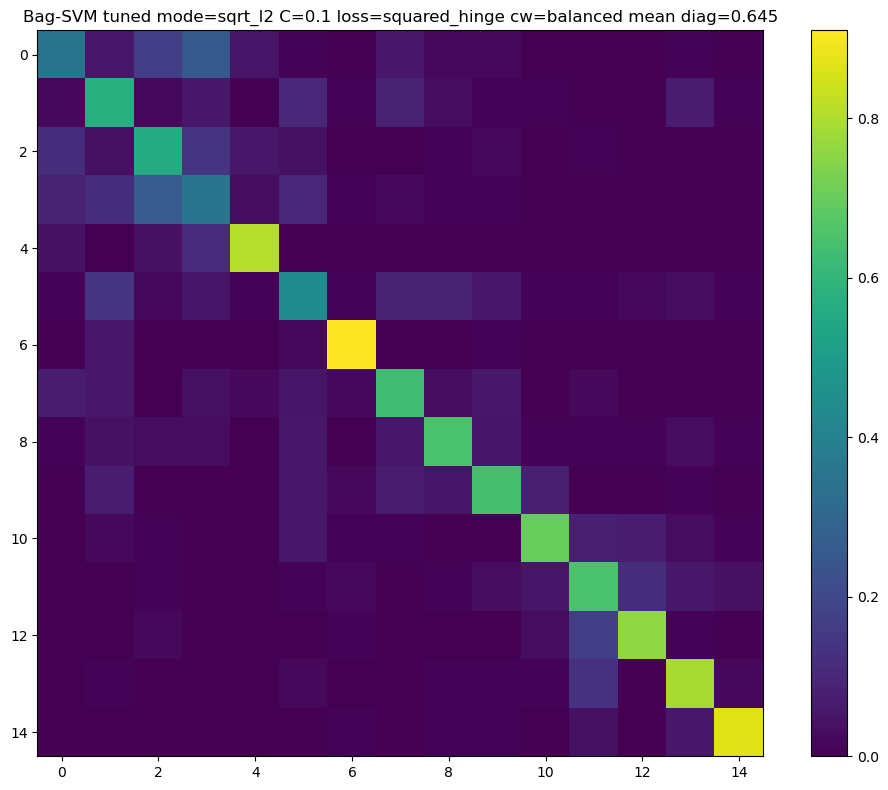

Saved to: outputs/opt_svm
Confusion matrix image: outputs/opt_svm/confusion_bag_svm_tuned_best.png
Best config: {'mode': 'sqrt_l2', 'C': 0.1, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'val_mean_diag': 0.6233333333333334}


In [23]:
# 保存调参日志、矩阵图和 npz 文件

np.savez(

    osp.join(OUTDIR, 'svm_search_results.npz'),

    results=np.array(results, dtype=object),

    best_cfg=np.array(best_cfg, dtype=object),

    test_score=mean_diag_test

)



with open(osp.join(OUTDIR, 'svm_search_log.txt'), 'w') as f:

    f.write('all configs:\n')

    for r in results:

        f.write(str(r) + '\n')

    f.write('\nbest_cfg=' + str(best_cfg) + '\n')

    f.write('test_mean_diag=' + str(mean_diag_test) + '\n')



cm_norm = cm_test.astype(float) / cm_test.sum(axis=1)[:, None]

plt.figure(figsize=(10, 8))

plt.imshow(cm_norm, cmap='viridis')

plt.title(

    f"Bag-SVM tuned mode={best_cfg['mode']} C={best_cfg['C']} "

    f"loss={best_cfg['loss']} cw={best_cfg['class_weight']} "

    f"mean diag={mean_diag_test:.3f}"

)

plt.colorbar()

plt.tight_layout()

png_path = osp.join(OUTDIR, 'confusion_bag_svm_tuned_best.png')

plt.savefig(png_path)

plt.show()



print('Saved to:', OUTDIR)

print('Confusion matrix image:', png_path)

print('Best config:', best_cfg)